# Euronext Quant Research Template
Week 3 sprint notebook: hypothesis -> backtest -> robustness -> memo.

## Research Objective
- Hypothesis: short-term reversal / momentum signal (replace with your idea).
- Universe: selected Euronext tickers.
- Evaluation: returns, Sharpe, max drawdown, turnover proxy.

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf

from dataclasses import dataclass

In [10]:
@dataclass
class ResearchConfig:
    tickers: tuple = ('AIR.PA', 'OR.PA', 'MC.PA', 'SAN.PA', 'BNP.PA')
    start: str = '2018-01-01'
    end: str = '2026-01-01'
    lookback: int = 5

cfg = ResearchConfig()
cfg

ResearchConfig(tickers=('AIR.PA', 'OR.PA', 'MC.PA', 'SAN.PA', 'BNP.PA'), start='2018-01-01', end='2026-01-01', lookback=5)

In [11]:
def load_close_prices(tickers, start, end):
    data = yf.download(list(tickers), start=start, end=end, auto_adjust=True, progress=False)
    close = data['Close'] if 'Close' in data else data
    close = close.dropna(how='all').sort_index()
    return close

prices = load_close_prices(cfg.tickers, cfg.start, cfg.end)
prices.tail()

Ticker,AIR.PA,BNP.PA,MC.PA,OR.PA,SAN.PA
Date,,,,,
2025-12-23,196.720001,80.610001,627.299988,362.549988,82.220001
2025-12-24,195.960007,80.519997,632.099976,363.799988,81.610001
2025-12-29,196.000000,80.220001,633.200012,365.299988,82.239998
2025-12-30,198.940002,81.099998,639.299988,366.950012,83.000000
2025-12-31,198.399994,80.790001,645.000000,366.600006,82.720001


In [12]:
def build_signal(prices, lookback=5):
    rets = prices.pct_change()
    signal = -rets.rolling(lookback).sum()
    return signal, rets

signal, rets = build_signal(prices, cfg.lookback)
signal.tail()

Ticker,AIR.PA,BNP.PA,MC.PA,OR.PA,SAN.PA
Date,,,,,
2025-12-23,-0.019624,-0.022099,0.014430,0.030058,-0.015880
2025-12-24,-0.029027,-0.005512,-0.000763,0.031962,0.006118
2025-12-29,-0.010114,0.000212,0.006520,0.028371,-0.001845
2025-12-30,-0.015837,-0.006271,-0.012056,0.010819,-0.007676
2025-12-31,-0.013736,-0.006791,-0.027304,-0.000491,-0.014013


In [13]:
def long_short_portfolio_returns(signal, rets):
    ranks = signal.rank(axis=1, pct=True)
    long_w = (ranks >= 0.8).astype(float)
    short_w = (ranks <= 0.2).astype(float)

    long_w = long_w.div(long_w.sum(axis=1), axis=0).fillna(0)
    short_w = short_w.div(short_w.sum(axis=1), axis=0).fillna(0)

    weights = long_w - short_w
    strategy_rets = (weights.shift(1) * rets).sum(axis=1).fillna(0)
    return strategy_rets

strategy_rets = long_short_portfolio_returns(signal, rets)
strategy_rets.tail()

Date
2025-12-23   -0.007253
2025-12-24    0.006666
2025-12-29    0.005717
2025-12-30   -0.007925
2025-12-31    0.000326
dtype: float64

In [14]:
def evaluate_strategy(strategy_rets, annualization=252):
    equity = (1 + strategy_rets).cumprod()
    ann_return = strategy_rets.mean() * annualization
    ann_vol = strategy_rets.std(ddof=0) * np.sqrt(annualization)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    rolling_max = equity.cummax()
    drawdown = equity / rolling_max - 1
    max_dd = drawdown.min()

    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'n_obs': int(strategy_rets.notna().sum())
    }, equity

metrics, equity = evaluate_strategy(strategy_rets)
metrics

{'ann_return': np.float64(0.05517574039332004),
 'ann_vol': np.float64(0.2891011244307971),
 'sharpe': np.float64(0.19085273536017533),
 'max_drawdown': -0.5393567001678207,
 'n_obs': 2049}

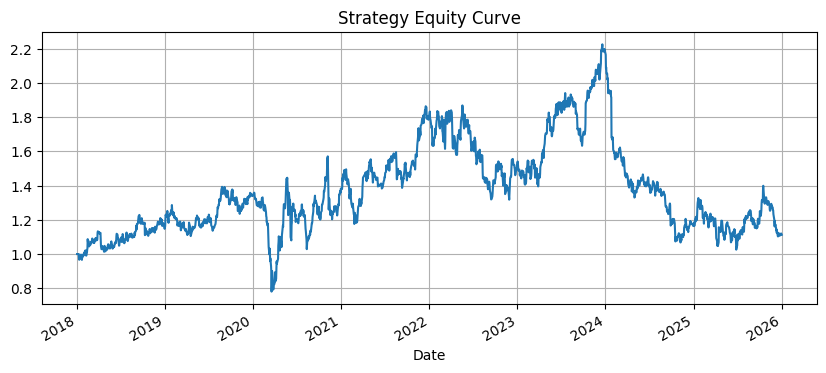

In [15]:
equity.plot(title='Strategy Equity Curve', figsize=(10, 4), grid=True);

## Robustness Checklist
- Run by subperiod (pre/post 2020, pre/post 2022).
- Sensitivity to lookback (3, 5, 10, 20).
- Add transaction costs and slippage assumptions.
- Neutralize by sector/market beta if needed.
- Document failure modes and kill criteria.